# Notebook 3 — TrOCR Fine-Tuning (Line-Level) — **Kaggle Edition**

Loads the **pre-segmented line images** + line-level ground truth produced
by `data_enhancement.ipynb` (section 10 writes
`data/splits/image_annotations.csv`) and fine-tunes TrOCR directly on
those line crops. Line segmentation, horizontal-projection detection, and
field-by-field ground-truth splitting all live in the enhancement
notebook — this notebook trusts the CSV.

### Kaggle setup

Upload the locally-generated `data/splits/` tree as a Kaggle dataset
(keeping the `processed/`, `augmented/`, `annotations/` subfolders and
`image_annotations.csv` at its root). Then point `KAGGLE_BASE_DIR` in
section 1 at whatever `/kaggle/input/<dataset-name>/...` path that tree
lives under. Checkpoints land in `/kaggle/working/` so they survive the
session and can be downloaded from the sidebar.

Reports both per-line CER and a full-prescription CER aggregated from the
line predictions grouped by `prescription_id`.


## 1. Setup


In [7]:
%matplotlib inline
import os, sys, json, random, re, csv, warnings, time
from collections import defaultdict
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, get_linear_schedule_with_warmup

try:
    import jiwer
except ImportError:
    jiwer = None
    print('[WARN] jiwer not installed — CER/WER metrics unavailable')

KAGGLE_BASE_DIR  = '/kaggle/input/datasets/benhammadilokmane/trocr-dataset/splits'
MAPPING_CSV      = os.path.join(KAGGLE_BASE_DIR, 'image_annotations.csv')
CHECKPOINT_DIR   = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


def strip_ocr(t):
    return re.sub(r'\s+', ' ', t.replace('<s_ocr>', '').replace('</s>', '')).strip()


def _resolve_kaggle_path(csv_rel_path):
    parts = csv_rel_path.replace('\\', '/').split('/')
    if len(parts) >= 2 and parts[0] == 'data' and parts[1] == 'splits':
        parts = parts[2:]
    return os.path.join(KAGGLE_BASE_DIR, *parts)


def load_line_samples(csv_path=MAPPING_CSV, sources=('processed', 'augmented')):
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(
            f'{csv_path} not found — verify the Kaggle dataset path '
            'and that image_annotations.csv sits at KAGGLE_BASE_DIR.')
    samples = []
    with open(csv_path, encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row['source'] not in sources:
                continue
            origin_id = row['origin_id']
            prescription_id = origin_id.split('/', 1)[0]
            samples.append({
                'id': os.path.splitext(os.path.basename(row['image_path']))[0],
                'prescription_id': prescription_id,
                'origin_id': origin_id,
                'image_path': _resolve_kaggle_path(row['image_path']),
                'source': row['source'],
                'text': row['ground_truth_clean'] or strip_ocr(row['ground_truth_raw']),
            })
    return samples


def make_splits(samples, train_ratio=0.8, val_ratio=0.1, seed=42):
    by_group = defaultdict(list)
    for s in samples:
        by_group[s['prescription_id']].append(s)
    groups = sorted(by_group.keys())
    random.Random(seed).shuffle(groups)
    n = len(groups)
    tr = int(n * train_ratio)
    va = int(n * val_ratio)
    train, val, test = [], [], []
    for g in groups[:tr]:        train.extend(by_group[g])
    for g in groups[tr:tr+va]:   val.extend(by_group[g])
    for g in groups[tr+va:]:     test.extend(by_group[g])
    return train, val, test


class PrescriptionLineDataset(Dataset):
    def __init__(self, samples, processor, max_length=128):
        self.samples = samples
        self.processor = processor
        self.max_length = max_length
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s['image_path']).convert('RGB')
        pv = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        text = s['text']
        labels = self.processor.tokenizer(text, padding='max_length',
                    max_length=self.max_length, truncation=True,
                    return_tensors='pt').input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {'pixel_values': pv, 'labels': labels, 'text': text}


class PrescriptionOCR(torch.nn.Module):
    def __init__(self, model_name='microsoft/trocr-small-handwritten'):
        super().__init__()
        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model.config.decoder_start_token_id = self.processor.tokenizer.cls_token_id
        self.model.config.pad_token_id = self.processor.tokenizer.pad_token_id
        self.model.config.eos_token_id = self.processor.tokenizer.sep_token_id
        self.model.config.max_length = 128
    def forward(self, pixel_values, labels=None):
        return self.model(pixel_values=pixel_values, labels=labels)
    def generate(self, pixel_values, max_length=128, num_beams=4):
        ids = self.model.generate(pixel_values, max_length=max_length, num_beams=num_beams)
        return self.processor.batch_decode(ids, skip_special_tokens=True)
    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.model.save_pretrained(path)
        self.processor.save_pretrained(path)
    @classmethod
    def load(cls, path):
        obj = cls.__new__(cls)
        torch.nn.Module.__init__(obj)
        obj.processor = TrOCRProcessor.from_pretrained(path)
        obj.model = VisionEncoderDecoderModel.from_pretrained(path)
        return obj


def compute_cer(preds, refs):
    if jiwer is None: return float('nan')
    return jiwer.cer(refs, preds)


def compute_word_accuracy(preds, refs):
    if jiwer is None: return float('nan')
    return 1.0 - jiwer.wer(refs, preds)


warnings.filterwarnings('ignore', category=FutureWarning)
print('Setup complete')
print(f'KAGGLE_BASE_DIR : {KAGGLE_BASE_DIR}  (exists={os.path.isdir(KAGGLE_BASE_DIR)})')
print(f'Mapping CSV     : {MAPPING_CSV}  (exists={os.path.isfile(MAPPING_CSV)})')
print(f'Checkpoint dir  : {CHECKPOINT_DIR}')


[WARN] jiwer not installed — CER/WER metrics unavailable
Setup complete
KAGGLE_BASE_DIR : /kaggle/input/datasets/benhammadilokmane/trocr-dataset/splits  (exists=True)
Mapping CSV     : /kaggle/input/datasets/benhammadilokmane/trocr-dataset/splits/image_annotations.csv  (exists=True)
Checkpoint dir  : /kaggle/working/checkpoints


## 2. Device & VRAM Check


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total')
    if free / 1e9 < 3.0:
        print('[WARNING] < 3 GB free — close other GPU apps before training')


Device: cuda
GPU: Tesla T4
VRAM: 12.70 GB free / 15.64 GB total


## 3. Baseline — Pretrained TrOCR (Before Fine-Tuning)

Run the off-the-shelf **`trocr-base-handwritten`** checkpoint on a handful
of pre-segmented line crops to establish a zero-shot reference point. The
fine-tuning itself in §6 uses `trocr-small-handwritten` (fits the session
VRAM budget more comfortably), but the baseline uses the larger checkpoint
because we're only doing inference here.


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


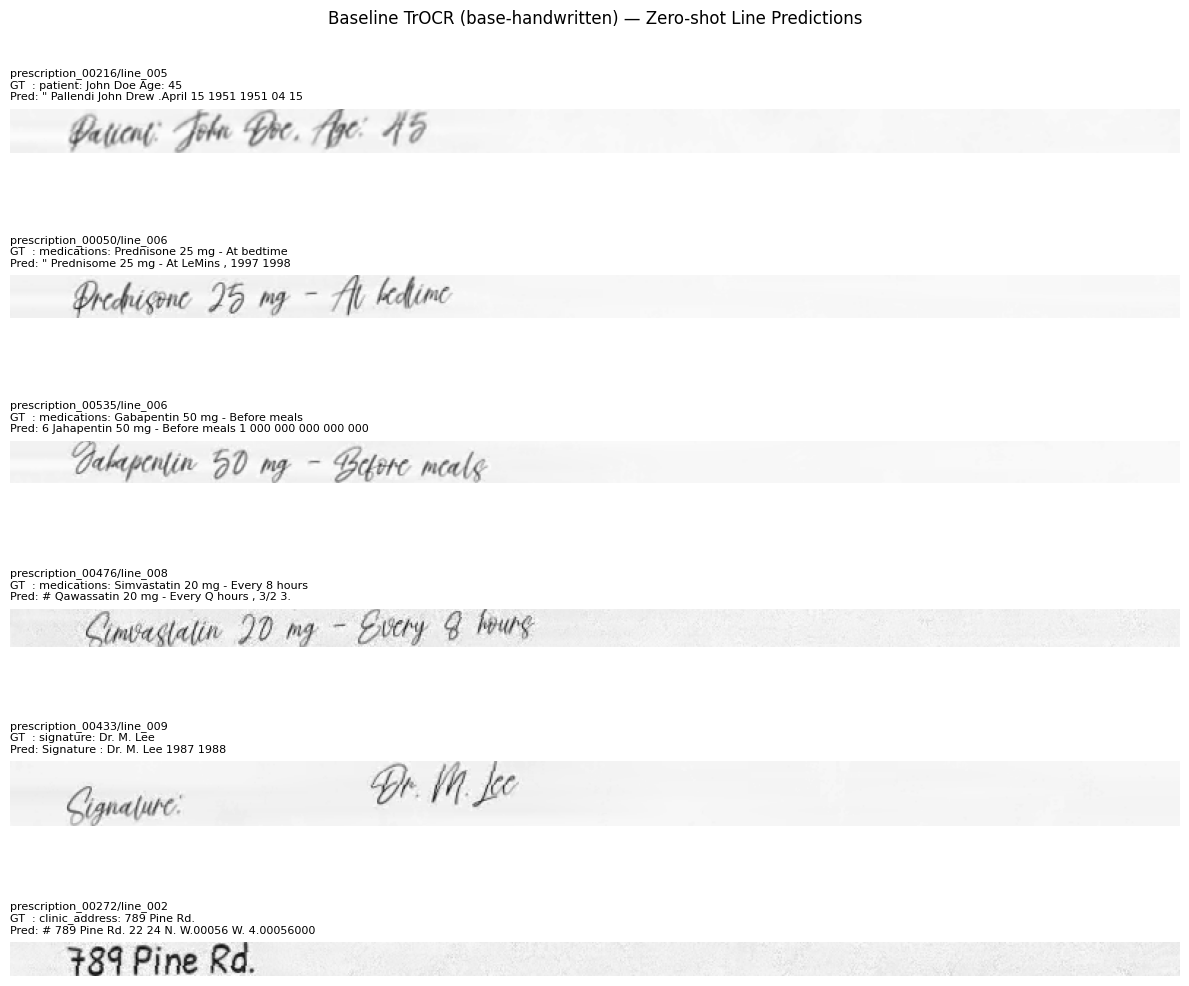


prescription_00216/line_005:
  GT  : patient: John Doe Age: 45
  Pred: " Pallendi John Drew .April 15 1951 1951 04 15

prescription_00050/line_006:
  GT  : medications: Prednisone 25 mg - At bedtime
  Pred: " Prednisome 25 mg - At LeMins , 1997 1998

prescription_00535/line_006:
  GT  : medications: Gabapentin 50 mg - Before meals
  Pred: 6 Jahapentin 50 mg - Before meals 1 000 000 000 000 000

prescription_00476/line_008:
  GT  : medications: Simvastatin 20 mg - Every 8 hours
  Pred: # Qawassatin 20 mg - Every Q hours , 3/2 3.

prescription_00433/line_009:
  GT  : signature: Dr. M. Lee
  Pred: Signature : Dr. M. Lee 1987 1988

prescription_00272/line_002:
  GT  : clinic_address: 789 Pine Rd.
  Pred: # 789 Pine Rd. 22 24 N. W.00056 W. 4.00056000


In [9]:
BASELINE_MODEL_NAME = 'microsoft/trocr-base-handwritten'
baseline_processor = TrOCRProcessor.from_pretrained(BASELINE_MODEL_NAME)
baseline_model = VisionEncoderDecoderModel.from_pretrained(BASELINE_MODEL_NAME).to(device)
baseline_model.eval()

preview_pool = [s for s in load_line_samples(MAPPING_CSV, sources=('processed',))
                if os.path.isfile(s['image_path'])]
chosen = random.sample(preview_pool, min(6, len(preview_pool)))

baseline_examples = []
for s in chosen:
    img = Image.open(s['image_path']).convert('RGB')
    pv = baseline_processor(images=img, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = baseline_model.generate(pv, max_length=128)
    pred = baseline_processor.batch_decode(ids, skip_special_tokens=True)[0]
    baseline_examples.append({'id': s['origin_id'], 'image': img, 'pred': pred, 'ref': s['text']})

n = len(baseline_examples)
fig, axes = plt.subplots(n, 1, figsize=(12, 1.8 * n))
if n == 1:
    axes = [axes]
for ax, ex in zip(axes, baseline_examples):
    ax.imshow(np.array(ex['image']))
    ax.set_title(f'{ex["id"]}\nGT  : {ex["ref"][:90]}\nPred: {ex["pred"][:90]}',
                 fontsize=8, loc='left')
    ax.axis('off')
plt.suptitle('Baseline TrOCR (base-handwritten) — Zero-shot Line Predictions', fontsize=12)
plt.tight_layout()
plt.show()

for ex in baseline_examples:
    print(f'\n{ex["id"]}:')
    print(f'  GT  : {ex["ref"][:120]}')
    print(f'  Pred: {ex["pred"][:120]}')


## 4. Build Line-Level Dataset & Splits

Load pre-segmented line crops + line-level ground truth directly from
`data/splits/image_annotations.csv`. Splits are grouped by
`prescription_id` so every line and every augmentation of the same
source prescription lives in exactly one split.


In [10]:
line_samples = load_line_samples(MAPPING_CSV, sources=('processed', 'augmented'))
n_proc = sum(1 for s in line_samples if s['source'] == 'processed')
n_aug  = len(line_samples) - n_proc
n_pres = len({s['prescription_id'] for s in line_samples})
print(f'Line-level samples : {len(line_samples)}  (processed: {n_proc}, augmented: {n_aug})')
print(f'Distinct prescriptions: {n_pres}')

train_samples, val_samples, test_samples = make_splits(line_samples)
print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

s0 = train_samples[0]
print(f'\nExample image : {os.path.relpath(s0["image_path"], KAGGLE_BASE_DIR)}')
print(f'Example origin: {s0["origin_id"]}')
print(f'Example label : {s0["text"]}')


Line-level samples : 25293  (processed: 8431, augmented: 16862)
Distinct prescriptions: 1000
Train: 20250 | Val: 2526 | Test: 2517

Example image : processed/prescription_00776/line_001.png
Example origin: prescription_00776/line_001
Example label : clinic_name: Greenwood Medical Center


## 5. DataLoaders


In [11]:
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-small-handwritten')

train_ds = PrescriptionLineDataset(train_samples, processor, max_length=128)
val_ds   = PrescriptionLineDataset(val_samples,   processor, max_length=128)
test_ds  = PrescriptionLineDataset(test_samples,  processor, max_length=128)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_loader))
print(f'pixel_values : {batch["pixel_values"].shape}')
print(f'labels       : {batch["labels"].shape}')
print(f'Batch OK ✓')


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

The image processor of type `DeiTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pixel_values : torch.Size([16, 3, 384, 384])
labels       : torch.Size([16, 128])
Batch OK ✓


## 6. Model Setup


In [12]:
ocr = PrescriptionOCR(model_name='microsoft/trocr-small-handwritten').to(device)

total_p  = sum(p.numel() for p in ocr.parameters() if p.requires_grad)
enc_p    = sum(p.numel() for p in ocr.model.encoder.parameters() if p.requires_grad)
dec_p    = sum(p.numel() for p in ocr.model.decoder.parameters() if p.requires_grad)
print(f'Trainable params — Total: {total_p:,}  |  Encoder: {enc_p:,}  |  Decoder: {dec_p:,}')


pytorch_model.bin:   0%|          | 0.00/246M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

Trainable params — Total: 61,596,672  |  Encoder: 21,960,192  |  Decoder: 39,636,480


## 7. Training Loop (5 Epochs, fp16)

AdamW + linear warmup + GradScaler. Tracks per-batch loss, epoch loss,
val CER, val word accuracy, and learning rate.


In [14]:
EPOCHS = 5
LR = 5e-5
optimizer = AdamW(ocr.parameters(), lr=LR, weight_decay=0.01)
total_steps = EPOCHS * len(train_loader)
warmup_steps = max(1, int(0.1 * total_steps))
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
use_fp16 = device.type == 'cuda'
scaler = GradScaler(enabled=use_fp16)
train_losses, val_cers, val_word_accs = [], [], []
batch_losses, lr_history = [], []
best_cer = float('inf')

ocr.model.config.max_length = None
ocr.model.generation_config.max_new_tokens = 128

for epoch in range(1, EPOCHS + 1):
    ocr.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    for batch in pbar:
        pv = batch['pixel_values'].to(device)
        lb = batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast(enabled=use_fp16):
            out = ocr(pv, labels=lb)
            loss = out.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(ocr.parameters(), 1.0)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() == scale_before:
            scheduler.step()
        batch_losses.append(loss.item())
        epoch_loss += loss.item()
        lr_history.append(scheduler.get_last_lr()[0])
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    ocr.eval()
    preds, refs = [], []
    with torch.no_grad():
        for batch in val_loader:
            pv = batch['pixel_values'].to(device)
            ids = ocr.model.generate(pv)
            preds.extend(ocr.processor.batch_decode(ids, skip_special_tokens=True))
            refs.extend(batch['text'])
    cer = compute_cer(preds, refs)
    wacc = compute_word_accuracy(preds, refs)
    val_cers.append(cer)
    val_word_accs.append(wacc)
    if cer < best_cer:
        best_cer = cer
        save_dir = os.path.join(CHECKPOINT_DIR, 'best_model')
        ocr.save(save_dir)
        print(f'  ★ New best line-CER={cer:.4f} — saved to {save_dir}')
    print(f'  Epoch {epoch}: loss={avg_loss:.4f}  line-CER={cer:.4f}  WordAcc={wacc:.4f}')
    if device.type == 'cuda':
        alloc = torch.cuda.memory_allocated() / 1e9
        print(f'  VRAM allocated: {alloc:.2f} GB')

Epoch 1/5: 100%|██████████| 1266/1266 [05:32<00:00,  3.80it/s, loss=0.0654]


  Epoch 1: loss=0.0418  line-CER=nan  WordAcc=nan
  VRAM allocated: 2.59 GB


Epoch 2/5: 100%|██████████| 1266/1266 [05:31<00:00,  3.82it/s, loss=0.0054]


  Epoch 2: loss=0.0287  line-CER=nan  WordAcc=nan
  VRAM allocated: 2.59 GB


Epoch 3/5: 100%|██████████| 1266/1266 [05:31<00:00,  3.82it/s, loss=0.0008]


  Epoch 3: loss=0.0181  line-CER=nan  WordAcc=nan
  VRAM allocated: 2.59 GB


Epoch 4/5: 100%|██████████| 1266/1266 [05:31<00:00,  3.82it/s, loss=0.0004]


  Epoch 4: loss=0.0118  line-CER=nan  WordAcc=nan
  VRAM allocated: 2.59 GB


Epoch 5/5: 100%|██████████| 1266/1266 [05:31<00:00,  3.82it/s, loss=0.0470]


  Epoch 5: loss=0.0057  line-CER=nan  WordAcc=nan
  VRAM allocated: 2.59 GB


## 8. Training Curves


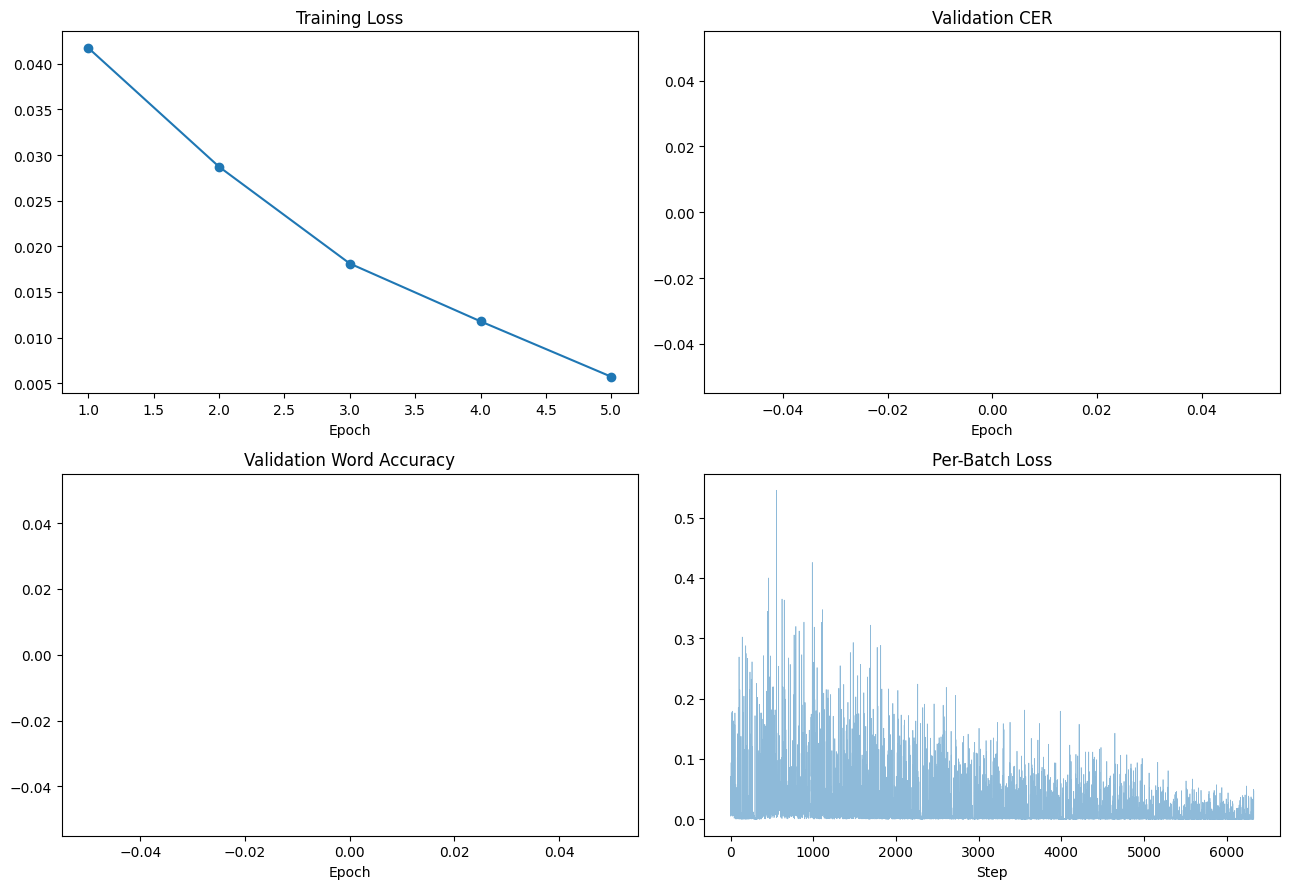

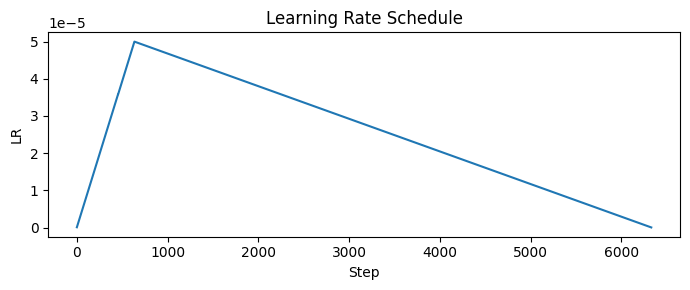

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs_ax = range(1, len(train_losses) + 1)

axes[0, 0].plot(epochs_ax, train_losses, 'o-')
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(epochs_ax, val_cers, 'o-', color='tab:red')
axes[0, 1].set_title('Validation CER')
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(epochs_ax, val_word_accs, 'o-', color='tab:green')
axes[1, 0].set_title('Validation Word Accuracy')
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(batch_losses, alpha=0.5, linewidth=0.5)
axes[1, 1].set_title('Per-Batch Loss')
axes[1, 1].set_xlabel('Step')

plt.tight_layout()
plt.show()

# LR schedule
plt.figure(figsize=(7, 3))
plt.plot(lr_history)
plt.title('Learning Rate Schedule')
plt.xlabel('Step')
plt.ylabel('LR')
plt.tight_layout()
plt.show()


## 9. Evaluation on Validation Lines

Show 6 random line crops from validation along with predicted text,
ground-truth text, and per-line CER.


Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


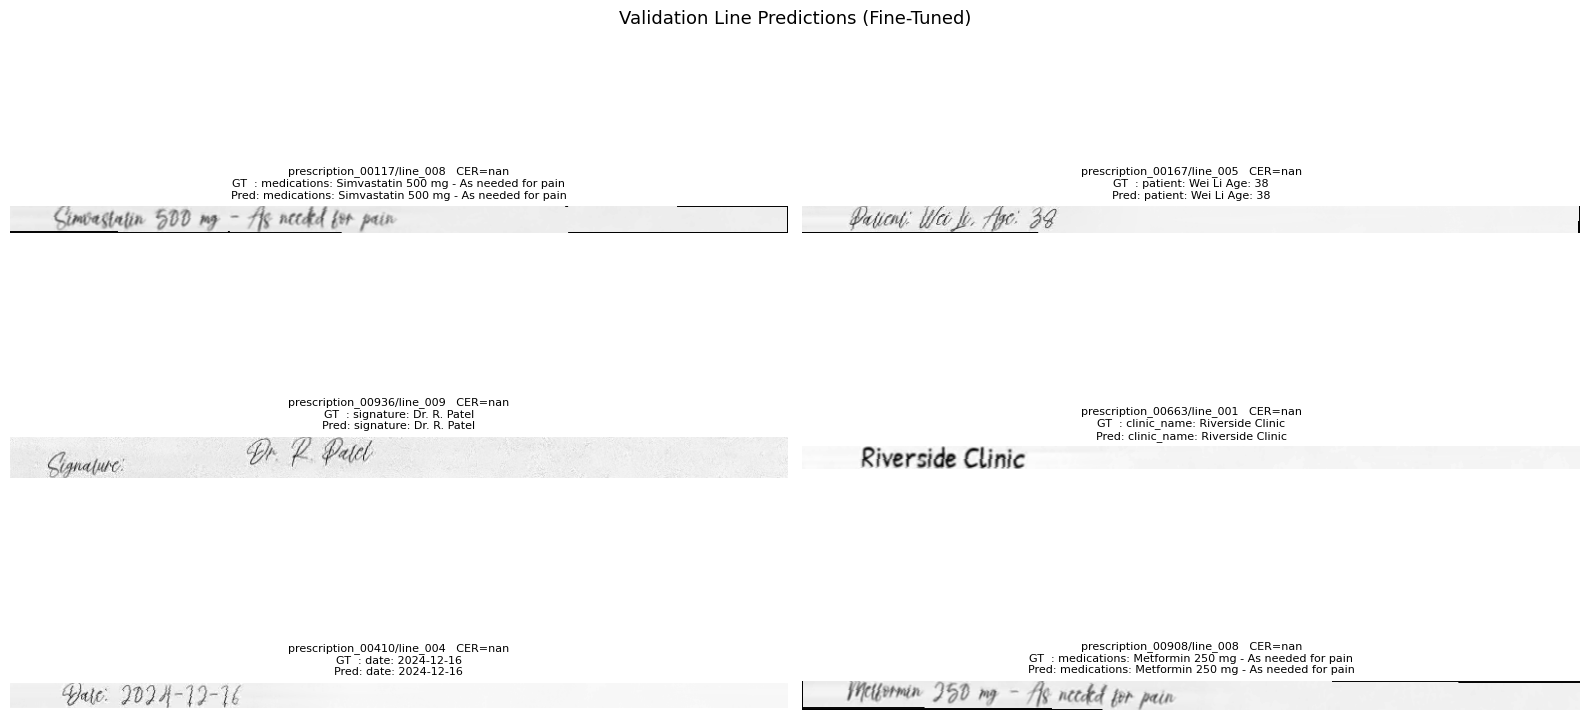

In [19]:
ocr.eval()
eval_subset = random.sample(val_samples, min(6, len(val_samples)))

fig, axes = plt.subplots(3, 2, figsize=(16, 9))
for ax, s in zip(axes.flatten(), eval_subset):
    img = Image.open(s['image_path']).convert('RGB')
    pv = processor(images=img, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = ocr.model.generate(pv, max_length=128)
    pred = processor.batch_decode(ids, skip_special_tokens=True)[0]
    ref = s['text']
    sample_cer = compute_cer([pred], [ref])

    ax.imshow(np.array(img))
    ax.set_title(f'{s["origin_id"]}   CER={sample_cer:.3f}\nGT  : {ref[:60]}\nPred: {pred[:60]}',
                 fontsize=8)
    ax.axis('off')

plt.suptitle('Validation Line Predictions (Fine-Tuned)', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Test Set Evaluation

Final held-out evaluation. We report **line-level CER** (the metric the
model was trained against) and **full-prescription CER** obtained by
joining all line predictions of the same origin image back together.


In [21]:
ocr.eval()
test_preds, test_refs = [], []
t0 = time.time()

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        pv = batch['pixel_values'].to(device)
        ids = ocr.model.generate(pv, max_length=128)
        test_preds.extend(processor.batch_decode(ids, skip_special_tokens=True))
        test_refs.extend(batch['text'])

elapsed = time.time() - t0
test_cer = compute_cer(test_preds, test_refs)
test_wacc = compute_word_accuracy(test_preds, test_refs)

by_pres_pred = defaultdict(list)
by_pres_ref  = defaultdict(list)
for s, p, r in zip(test_samples, test_preds, test_refs):
    by_pres_pred[s['prescription_id']].append((s['origin_id'], p))
    by_pres_ref[s['prescription_id']].append((s['origin_id'], r))

prescriptions = sorted(by_pres_pred.keys())
full_preds, full_refs = [], []
for pres in prescriptions:
    preds_sorted = [p for _, p in sorted(by_pres_pred[pres], key=lambda t: t[0])]
    refs_sorted  = [r for _, r in sorted(by_pres_ref[pres],  key=lambda t: t[0])]
    full_preds.append(' '.join(preds_sorted))
    full_refs.append(' '.join(refs_sorted))

full_cer  = compute_cer(full_preds, full_refs)
full_wacc = compute_word_accuracy(full_preds, full_refs)

print('═' * 48)
print(f'  Line-level CER             : {test_cer:.4f}')
print(f'  Line-level Word Accuracy   : {test_wacc:.4f}')
print(f'  Test lines                 : {len(test_preds)}')
print(f'  Inference time             : {elapsed:.1f}s ({elapsed/len(test_preds):.2f}s/line)')
print('-' * 48)
print(f'  Full-prescription CER      : {full_cer:.4f}')
print(f'  Full-prescription Word Acc : {full_wacc:.4f}')
print(f'  Distinct prescriptions     : {len(prescriptions)}')
print('═' * 48)


Test inference: 100%|██████████| 158/158 [01:03<00:00,  2.49it/s]

════════════════════════════════════════════════
  Line-level CER             : nan
  Line-level Word Accuracy   : nan
  Test lines                 : 2517
  Inference time             : 63.4s (0.03s/line)
------------------------------------------------
  Full-prescription CER      : nan
  Full-prescription Word Acc : nan
  Distinct prescriptions     : 100
════════════════════════════════════════════════


## 11. Before vs After Comparison


In [22]:
val_by_pres = defaultdict(list)
for s in val_samples:
    if s['source'] == 'processed':
        val_by_pres[s['prescription_id']].append(s)

chosen_pres = random.sample(list(val_by_pres.keys()),
                            min(4, len(val_by_pres)))

rows = []
for pres in chosen_pres:
    # Order by line stem (line_001, line_002, …) to reconstruct top-to-bottom.
    lines = sorted(val_by_pres[pres], key=lambda s: s['origin_id'])

    base_lines, ft_lines, ref_lines = [], [], []
    for ls in lines:
        img = Image.open(ls['image_path']).convert('RGB')
        pv_b = baseline_processor(images=img, return_tensors='pt').pixel_values.to(device)
        pv_f = processor(images=img, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids_b = baseline_model.generate(pv_b, max_length=128)
            ids_f = ocr.model.generate(pv_f, max_length=128)
        base_lines.append(baseline_processor.batch_decode(ids_b, skip_special_tokens=True)[0])
        ft_lines.append(processor.batch_decode(ids_f, skip_special_tokens=True)[0])
        ref_lines.append(ls['text'])

    pred_b = ' '.join(base_lines)
    pred_f = ' '.join(ft_lines)
    ref = ' '.join(ref_lines)
    cer_b = compute_cer([pred_b], [ref])
    cer_f = compute_cer([pred_f], [ref])
    rows.append([pres, f'{cer_b:.3f}', f'{cer_f:.3f}',
                 ref[:50] + '…', pred_b[:50] + '…', pred_f[:50] + '…'])

headers = ['Prescription', 'CER (base)', 'CER (fine-tuned)',
           'Ground Truth', 'Baseline', 'Fine-Tuned']
try:
    from tabulate import tabulate
    print(tabulate(rows, headers=headers, tablefmt='github'))
except ImportError:
    print('\t'.join(headers))
    for r in rows:
        print('\t'.join(r))


Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


| Prescription       |   CER (base) |   CER (fine-tuned) | Ground Truth                                        | Baseline                                            | Fine-Tuned                                          |
|--------------------|--------------|--------------------|-----------------------------------------------------|-----------------------------------------------------|-----------------------------------------------------|
| prescription_00003 |          nan |                nan | clinic_name: Meadowview Health clinic_address: 678… | 4 Meadowview Health53000500005000050000500005 6278… | clinic_name: Meadowview Health clinic_address: 678… |
| prescription_00787 |          nan |                nan | clinic_name: Oakview Hospital clinic_address: 234 … | 2 1 Oakview Hospital53 242522222222222222222222222… | clinic_name: Oakview Hospital clinic_address: 234 … |
| prescription_00065 |          nan |                nan | clinic_name: Meadowview Health clinic_address: 123… | Mea

## 12. Save Final Model


In [23]:
save_dir = os.path.join(CHECKPOINT_DIR, 'best_model')
ocr.save(save_dir)
print(f'Model saved to: {save_dir}')
print('Files:', os.listdir(save_dir)[:8])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/checkpoints/best_model
Files: ['generation_config.json', 'tokenizer_config.json', 'processor_config.json', 'tokenizer.json', 'model.safetensors', 'config.json']
